In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv('OrderDetails_2026_03_15-2026_06_15.csv')
df.info()
df.head(10)
df.dropna()
df = df[df['Amount'] > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3254 entries, 0 to 3253
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Opened           3254 non-null   object 
 1   # of Guests      3254 non-null   int64  
 2   Table            3084 non-null   object 
 3   Discount Amount  3254 non-null   float64
 4   Amount           3254 non-null   float64
 5   Tax              3254 non-null   float64
 6   Tip              3254 non-null   float64
 7   Gratuity         3254 non-null   float64
 8   Closed           3238 non-null   object 
dtypes: float64(5), int64(1), object(3)
memory usage: 228.9+ KB


In [23]:
df['Amount'].sort_values(ascending=False)

1320    4704.00
1638    1672.00
2887    1378.64
3144    1258.00
3207    1130.00
         ...   
2549       8.50
1322       7.00
1316       4.00
1319       1.00
3044       0.01
Name: Amount, Length: 3088, dtype: float64

In [24]:
opened_dt = pd.to_datetime(df['Opened'], format='%m/%d/%y %I:%M %p')
closed_dt = pd.to_datetime(df['Closed'], format='%m/%d/%y %I:%M %p')

df.insert(0, 'Date', opened_dt.dt.strftime('%m/%d/%y'))
df['Duration'] = (closed_dt - opened_dt).dt.total_seconds() / 60  # minutes
df['Duration'].info()
df = df[df['Duration'] >= 15]

df['Opened'] = opened_dt.dt.strftime('%I:%M %p')
df['Closed'] = closed_dt.dt.strftime('%I:%M %p')

df.head(10)

<class 'pandas.core.series.Series'>
Index: 3088 entries, 0 to 3252
Series name: Duration
Non-Null Count  Dtype  
--------------  -----  
3088 non-null   float64
dtypes: float64(1)
memory usage: 48.2 KB


,Date,Opened,# of Guests,Table,Discount Amount,Amount,Tax,Tip,Gratuity,Closed,Duration
0,03/15/26,04:04 PM,6,BD1,0.0,335.0,30.58,20.00,67.0,07:05 PM,181.0
1,03/15/26,04:04 PM,4,O1,0.0,232.0,21.20,50.76,0.0,06:10 PM,126.0
2,03/15/26,04:31 PM,4,O4,5.2,416.8,38.03,0.00,0.0,08:15 PM,224.0
3,03/15/26,04:18 PM,2,B12,0.0,133.0,12.14,20.00,0.0,12:21 AM,483.0
4,03/15/26,04:42 PM,2,O7,0.0,74.0,6.76,15.00,0.0,06:35 PM,113.0
5,03/15/26,04:58 PM,2,O6,0.0,144.0,13.11,0.00,0.0,08:01 PM,183.0
7,03/15/26,05:51 PM,4,O10,0.0,198.0,18.07,40.00,0.0,07:54 PM,123.0
8,03/15/26,06:56 PM,5,O1,0.0,122.0,11.15,15.00,0.0,08:46 PM,110.0
9,03/15/26,06:57 PM,7,BD1,0.0,89.0,8.11,0.00,0.0,08:03 PM,66.0
10,03/15/26,07:14 PM,2,B12,0.0,128.0,11.67,0.00,0.0,12:19 AM,305.0


In [25]:
# df['Table'].split()

# Value per Person per 15 Minutes

In [26]:
df['VPCPM'] = (df['Amount'] / df['# of Guests']) / (df['Duration'] / 15)
df['VPCPM'].head(10)
df['Mean VPCPM'] = df['# of Guests'].map(df.groupby('# of Guests')['VPCPM'].mean()) # understand why this works
df.head(20).sort_values(by = 'VPCPM', ascending = False)

,Date,Opened,# of Guests,Table,Discount Amount,Amount,Tax,Tip,Gratuity,Closed,Duration,VPCPM,Mean VPCPM
11,03/15/26,07:15 PM,1,B6,0.0,244.0,22.28,40.00,0.0,12:21 AM,306.0,11.960784,8.857137
17,03/15/26,09:06 PM,2,O6,0.0,90.0,8.23,41.77,0.0,10:09 PM,63.0,10.714286,5.733103
15,03/15/26,08:43 PM,2,O3,0.0,146.0,13.35,41.65,0.0,10:54 PM,131.0,8.358779,5.733103
21,03/15/26,10:44 PM,2,B11,0.0,97.0,8.84,30.00,0.0,12:20 AM,96.0,7.578125,5.733103
2,03/15/26,04:31 PM,4,O4,5.2,416.8,38.03,0.00,0.0,08:15 PM,224.0,6.977679,4.901690
1,03/15/26,04:04 PM,4,O1,0.0,232.0,21.20,50.76,0.0,06:10 PM,126.0,6.904762,4.901690
18,03/15/26,09:42 PM,4,O10,0.0,204.0,18.63,44.88,0.0,11:38 PM,116.0,6.594828,4.901690
7,03/15/26,05:51 PM,4,O10,0.0,198.0,18.07,40.00,0.0,07:54 PM,123.0,6.036585,4.901690
5,03/15/26,04:58 PM,2,O6,0.0,144.0,13.11,0.00,0.0,08:01 PM,183.0,5.901639,5.733103
13,03/15/26,08:34 PM,4,O1,0.0,270.0,24.66,41.00,0.0,11:30 PM,176.0,5.752841,4.901690


In [27]:
# df.groupby('# of Guests')['VPCPM'].agg(['mean', 'count', 'min', 'max'])
# # df[df['# of Guests'] == 1][['Amount', 'Duration', 'VPCPM']]
df.groupby('# of Guests')['VPCPM'].mean().reset_index().rename(columns={'VPCPM': 'Mean VPCPM'})

,# of Guests,Mean VPCPM
0,1,8.857137
1,2,5.733103
2,3,4.430396
3,4,4.901690
4,5,4.571585
5,6,4.384803
6,7,3.544131
7,8,4.297918
8,9,3.873501
9,10,4.928839


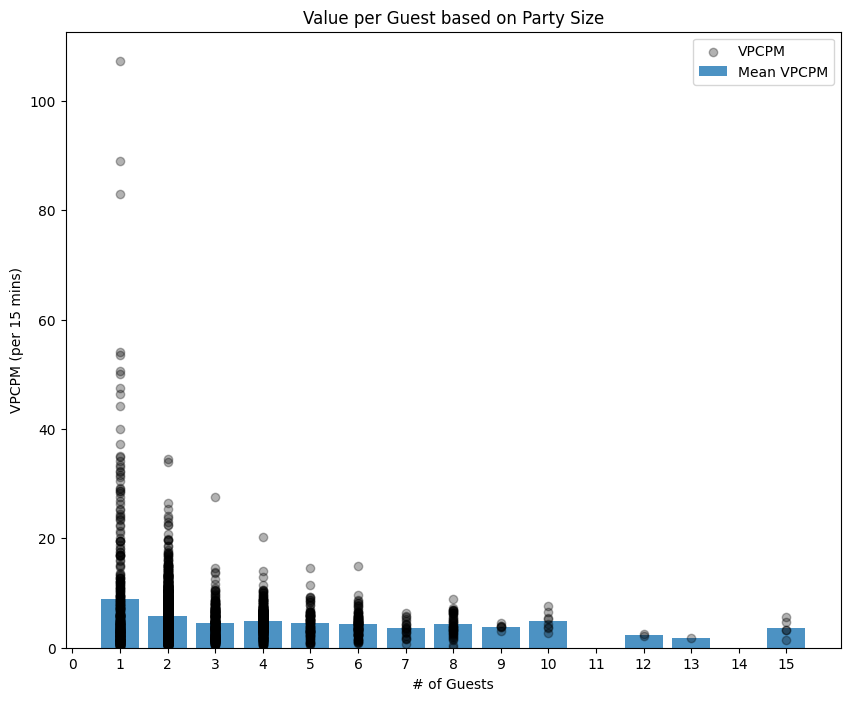

In [28]:
import matplotlib.pyplot as plt

mean_vpcpm = df.groupby('# of Guests')['VPCPM'].mean()
fig, ax = plt.subplots(figsize = (10,8))

ax.bar(mean_vpcpm.index, mean_vpcpm, alpha = 0.8)
ax.scatter(df['# of Guests'], df['VPCPM'], alpha=0.3, color='black')

plt.title('Value per Guest based on Party Size')
plt.xlabel('# of Guests')
plt.ylabel('VPCPM (per 15 mins)')
plt.legend(['VPCPM', 'Mean VPCPM'],loc = 'best')
plt.xticks(range(0,16)); # semi-colon prevents text output 

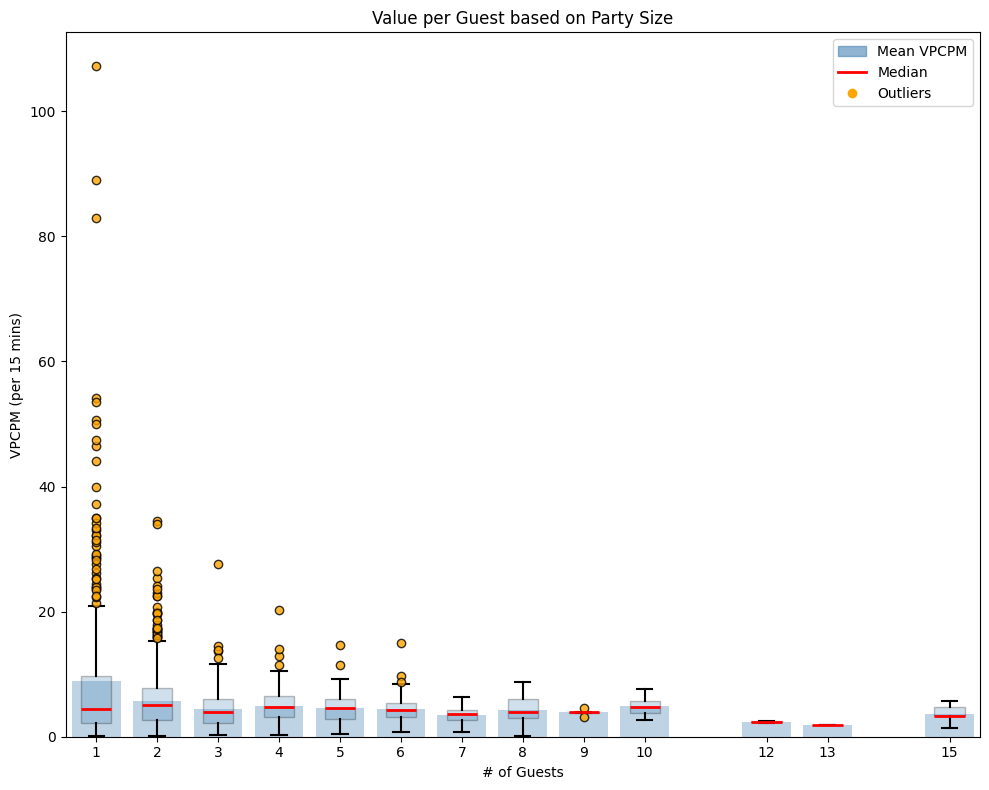

In [29]:
import matplotlib.pyplot as plt

mean_vpcpm = df.groupby('# of Guests')['VPCPM'].mean()
guest_sizes = sorted(df['# of Guests'].unique())
groups = [df[df['# of Guests'] == g]['VPCPM'].values for g in guest_sizes]

fig, ax = plt.subplots(figsize=(10, 8))

ax.bar(mean_vpcpm.index, mean_vpcpm, alpha=0.35, color='steelblue', zorder=1)

ax.boxplot(groups, positions=guest_sizes, widths=0.5,
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.25),
           medianprops=dict(color='red', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor='orange', markersize=6, alpha=0.8),
           whiskerprops=dict(linewidth=1.5),
           capprops=dict(linewidth=1.5),
           zorder=2)

ax.set_xticks(guest_sizes)
ax.set_xlabel('# of Guests')
ax.set_ylabel('VPCPM (per 15 mins)')
ax.set_title('Value per Guest based on Party Size')

handles = [
    plt.Rectangle((0, 0), 1, 1, color='steelblue', alpha=0.6),
    plt.Line2D([0], [0], color='red', linewidth=2),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=8),
]
ax.legend(handles, ['Mean VPCPM', 'Median', 'Outliers'], loc='best')
plt.tight_layout()
plt.show()

## Who Spends More Per Hour? — Descriptive Analysis by Party Size

## Seating Sections & Capacity

Splitting `Table` into its section (Bar, Black Duck, Evangeline, Open Lounge) and attaching each table's seat capacity, so value-per-party-size can be compared *within* a section instead of pooled across very different seating types (a 1-seat bar stool behaves nothing like a 5-top).

Black Duck and Evangeline capacities aren't confirmed per-table-number, so they're **inferred** from each table's most frequent (`mode`) `# of Guests`. Max was tried first but is dominated by combined-table parties (e.g. BD3/BD5 have recorded parties up to 15) — mode recovers Evangeline's known layout cleanly (two 2-seaters + one flexible 5-6 seater) but Black Duck doesn't resolve as cleanly, so `MANUAL_CAPACITY_OVERRIDES` below exists to be filled in once the real floor plan is confirmed (see README).

In [30]:
def get_section(table):
    if pd.isna(table):
        return 'Unknown/To-Go'
    if table.startswith('BD'):
        return 'Black Duck'
    if table.startswith('B'):
        return 'Bar'
    if table.startswith('E'):
        return 'Evangeline'
    if table.startswith('O'):
        return 'Open Lounge'
    return 'Unknown'

df['Section'] = df['Table'].map(get_section)

TABLE_CAPACITY = {}
TABLE_CAPACITY.update({f'B{i}': 1 for i in range(1, 13)})  # B13/B14 unconfirmed, excluded on purpose
TABLE_CAPACITY.update({f'O{i}': 3 if i in (1, 8, 10) else 2 for i in range(1, 11)})

# Mode (most frequent party size), not max — large parties get seated across combined
# tables under one anchor table code, so max is dominated by those outliers.
mode_guests_seen = df.groupby('Table')['# of Guests'].agg(lambda s: s.mode().iloc[0])
for table, mode_seen in mode_guests_seen.items():
    if table.startswith('BD'):
        TABLE_CAPACITY[table] = 4 if mode_seen <= 4 else 5
    elif table.startswith('E'):
        TABLE_CAPACITY[table] = 2 if mode_seen <= 2 else 6  # flexible 5-6 seater modeled as 6

# Fill in once the real floor-plan mapping is confirmed, e.g. {'BD1': 4, 'BD3': 5} —
# overrides the mode-based estimate above without touching the inference logic.
MANUAL_CAPACITY_OVERRIDES = {}
TABLE_CAPACITY.update(MANUAL_CAPACITY_OVERRIDES)

df['Capacity'] = df['Table'].map(TABLE_CAPACITY)
df[['Table', 'Section', 'Capacity']].drop_duplicates().sort_values(['Section', 'Table'])

,Table,Section,Capacity
20,B1,Bar,1.0
44,B10,Bar,1.0
21,B11,Bar,1.0
3,B12,Bar,1.0
1577,B13,Bar,NaN
38,B14,Bar,NaN
288,B2,Bar,1.0
30,B3,Bar,1.0
95,B4,Bar,1.0
35,B5,Bar,1.0


In [31]:
unassigned = df[df['Capacity'].isna() & df['Table'].notna()]
print('Tables with no capacity assigned (excluded from capacity-based analysis):')
print(unassigned['Table'].value_counts())

overbooked = df[df['# of Guests'] > df['Capacity']]
print(f'\nRows exceeding assigned capacity ({len(overbooked)}) — sanity-check for the inferred Black Duck/Evangeline capacities:')
overbooked[['Table', 'Section', 'Capacity', '# of Guests', 'Amount']]

Tables with no capacity assigned (excluded from capacity-based analysis):
Table
B14    14
B13     7
Name: count, dtype: int64

Rows exceeding assigned capacity (1432) — sanity-check for the inferred Black Duck/Evangeline capacities:


,Table,Section,Capacity,# of Guests,Amount
0,BD1,Black Duck,5.0,6,335.0
1,O1,Open Lounge,3.0,4,232.0
2,O4,Open Lounge,2.0,4,416.8
3,B12,Bar,1.0,2,133.0
7,O10,Open Lounge,3.0,4,198.0
...,...,...,...,...,...
3245,E3,Evangeline,6.0,7,250.0
3246,B12,Bar,1.0,2,71.0
3248,O5,Open Lounge,2.0,3,255.0
3249,B12,Bar,1.0,2,51.0


## Bar vs. Table Seating

The bar (12 single-guest stools) and the table sections (Black Duck, Evangeline, Open Lounge) serve very different party-size ranges, so VPCPM is plotted separately for each rather than pooled.

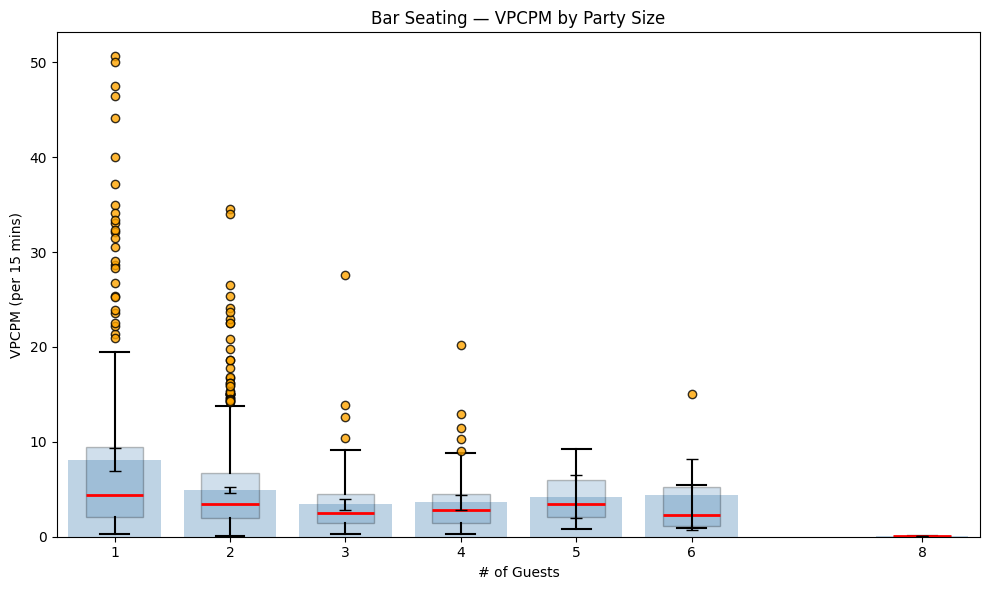

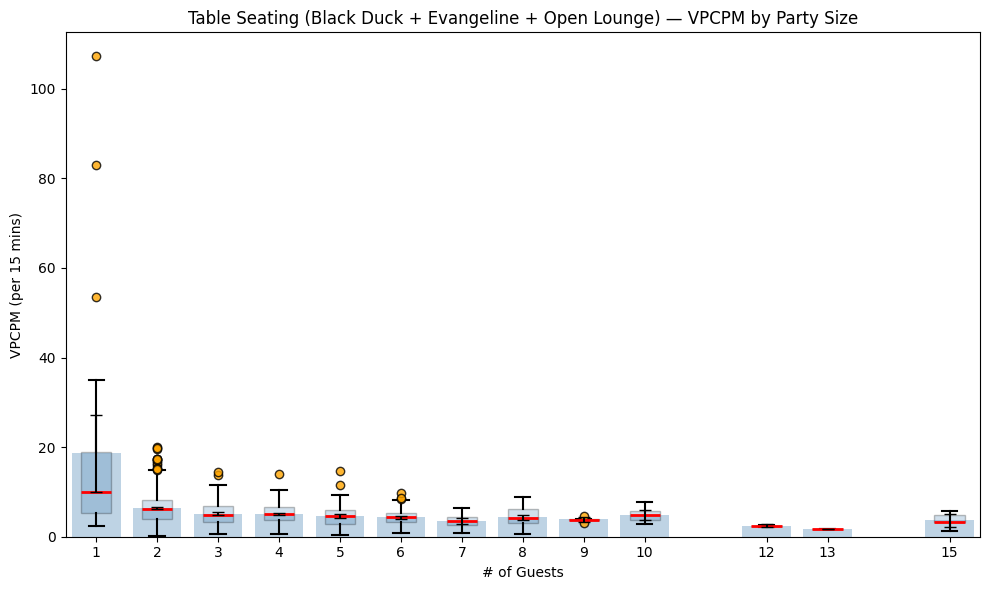

In [32]:
def plot_vpcpm_by_party_size(sub_df, title):
    grouped = sub_df.groupby('# of Guests')['VPCPM']
    mean_vpcpm = grouped.mean()
    sem_vpcpm = grouped.sem().fillna(0)
    guest_sizes = sorted(sub_df['# of Guests'].unique())
    groups = [sub_df[sub_df['# of Guests'] == g]['VPCPM'].values for g in guest_sizes]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(mean_vpcpm.index, mean_vpcpm, alpha=0.35, color='steelblue', zorder=1)
    ax.errorbar(mean_vpcpm.index, mean_vpcpm, yerr=1.96 * sem_vpcpm,
                fmt='none', ecolor='black', elinewidth=1.5, capsize=4, zorder=3)
    ax.boxplot(groups, positions=guest_sizes, widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.25),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='orange', markersize=6, alpha=0.8),
               whiskerprops=dict(linewidth=1.5),
               capprops=dict(linewidth=1.5),
               zorder=2)
    ax.set_xticks(guest_sizes)
    ax.set_xlabel('# of Guests')
    ax.set_ylabel('VPCPM (per 15 mins)')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

bar_df = df[df['Section'] == 'Bar']
table_df = df[df['Section'].isin(['Black Duck', 'Evangeline', 'Open Lounge'])]

plot_vpcpm_by_party_size(bar_df, 'Bar Seating — VPCPM by Party Size')
plot_vpcpm_by_party_size(table_df, 'Table Seating (Black Duck + Evangeline + Open Lounge) — VPCPM by Party Size')

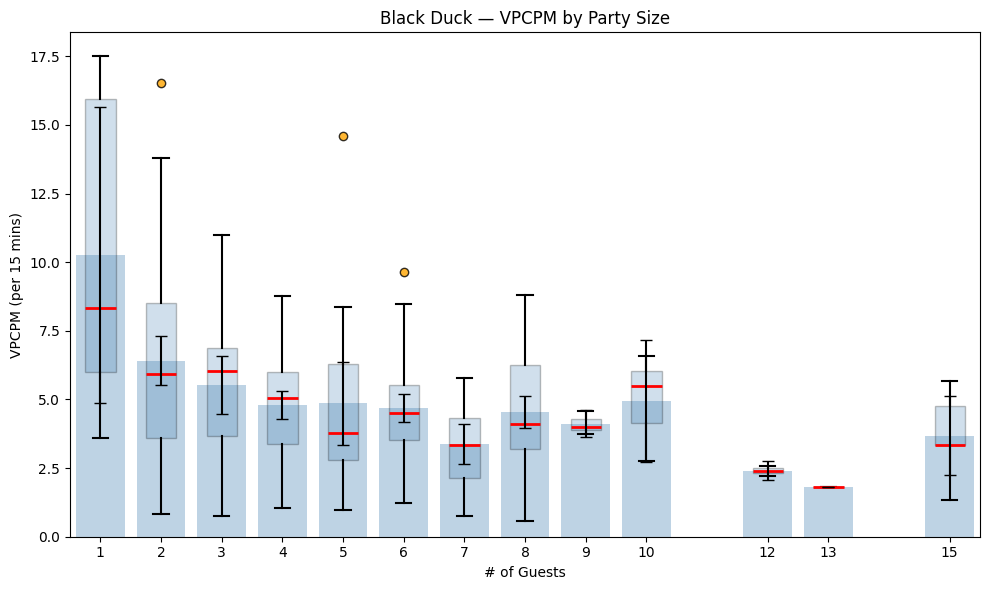

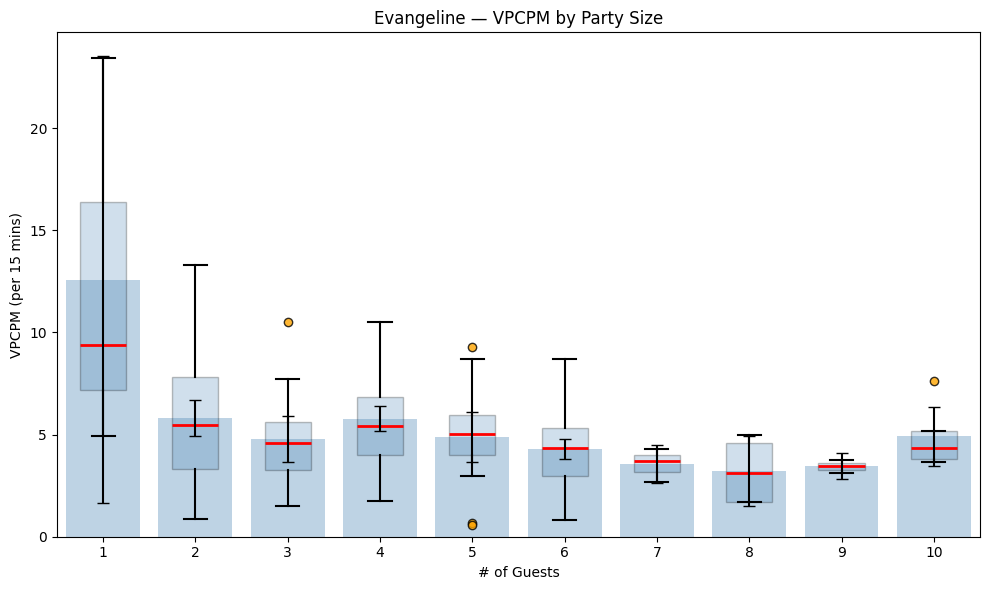

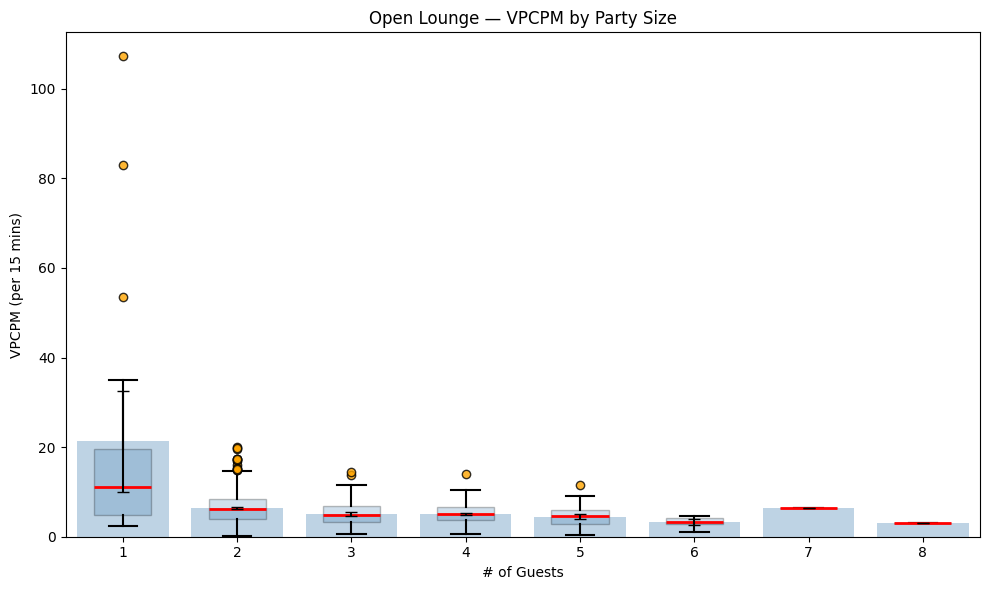

In [33]:
for section in ['Black Duck', 'Evangeline', 'Open Lounge']:
    plot_vpcpm_by_party_size(df[df['Section'] == section], f'{section} — VPCPM by Party Size')

## Table-Level Revenue Rate (TPCPM)

VPCPM normalizes by guest count, which is useful for per-seat comparisons but can obscure how much a table earns in total. **TPCPM** (Total revenue Per table, Per 15 Minutes) = `Amount / (Duration / 15)` answers the capacity-planning question directly: for a table of a given size, does a full party or a smaller one generate more $/15min?

In [34]:
df['TPCPM'] = df['Amount'] / (df['Duration'] / 15)

df.groupby(['Section', '# of Guests'])['TPCPM'].agg(['mean', 'count']).round(2)

mean  count
Section       # of Guests              
Bar           1             8.12    244
              2             9.87    699
              3            10.20    133
              4            14.53     67
              5            21.12      7
              6            26.51      7
              8             0.95      1
Black Duck    1            10.28      5
              2            12.81     59
              3            16.62     24
              4            19.20     55
              5            24.27     17
              6            28.08     50
              7            23.64     17
              8            36.27     41
              9            37.04      3
              10           49.44      3
              12           28.84      2
              13           23.41      1
              15           55.23      5
Evangeline    1            12.58      3
              2            11.63     61
              3            14.36     15
              4            23.12     47
              5            24.37     15
              6            25.77     52
              7            24.89      3
              8            25.74      4
              9            31.04      2
              10           49.20      5
Open Lounge   1            21.31     22
              2            12.79    779
              3            15.30    157
              4            20.47    229
              5            22.25     57
              6            20.13     10
              7            44.46      1
              8            24.96      1
Unknown/To-Go 1             7.65     94
              2             1.49      1
              9            35.96      1

## Section Summary & Recommendations

Ranking party sizes within each section by a **shrinkage-weighted VPCPM** score — low-order-count party sizes get pulled toward their section's overall mean (weight = that section's median order count), so a party size backed by only a couple of orders can't outrank one backed by dozens purely on noise. Raw mean, its 95% CI, and TPCPM are shown alongside for transparency.

In [35]:
summary = (
    df.groupby(['Section', '# of Guests'])
      .agg(**{
          'Mean VPCPM': ('VPCPM', 'mean'),
          'SEM VPCPM': ('VPCPM', 'sem'),
          'Mean TPCPM': ('TPCPM', 'mean'),
          'SEM TPCPM': ('TPCPM', 'sem'),
          'Orders': ('VPCPM', 'count'),
      })
      .reset_index()
)
summary['95% CI VPCPM'] = 1.96 * summary['SEM VPCPM'].fillna(0)
summary['95% CI TPCPM'] = 1.96 * summary['SEM TPCPM'].fillna(0)

# Shrinkage-weighted score: pulls low-order party sizes toward their section's overall
# mean (k = that section's median order count), so a handful of orders can't outrank
# a party size backed by dozens of them.
section_means = df.groupby('Section')[['VPCPM', 'TPCPM']].mean()
summary['Section Mean VPCPM'] = summary['Section'].map(section_means['VPCPM'])
summary['Section Mean TPCPM'] = summary['Section'].map(section_means['TPCPM'])
k = summary.groupby('Section')['Orders'].transform('median')
n = summary['Orders']
summary['Weighted VPCPM'] = (n / (n + k)) * summary['Mean VPCPM'] + (k / (n + k)) * summary['Section Mean VPCPM']
summary['Weighted TPCPM'] = (n / (n + k)) * summary['Mean TPCPM'] + (k / (n + k)) * summary['Section Mean TPCPM']

display_cols = ['# of Guests', 'Mean VPCPM', '95% CI VPCPM', 'Weighted VPCPM', 'Mean TPCPM', 'Weighted TPCPM', 'Orders']
for section in ['Bar', 'Black Duck', 'Evangeline', 'Open Lounge']:
    print(f'\n=== {section} - ranked by Weighted VPCPM ===')
    print(summary[summary['Section'] == section][display_cols].sort_values('Weighted VPCPM', ascending=False).round(2).to_string(index=False))


=== Bar - ranked by Weighted VPCPM ===
 # of Guests  Mean VPCPM  95% CI VPCPM  Weighted VPCPM  Mean TPCPM  Weighted TPCPM  Orders
           1        8.12          1.25            7.52        8.12            8.52     244
           8        0.12          0.00            5.27        0.95            9.84       1
           6        4.42          3.72            5.26       26.51           11.54       7
           5        4.22          2.24            5.24       21.12           11.03       7
           2        4.94          0.33            4.97        9.87            9.88     699
           4        3.63          0.81            4.49       14.53           12.25      67
           3        3.40          0.55            4.05       10.20           10.12     133

=== Black Duck - ranked by Weighted VPCPM ===
 # of Guests  Mean VPCPM  95% CI VPCPM  Weighted VPCPM  Mean TPCPM  Weighted TPCPM  Orders
           1       10.28          5.39            6.28       10.28           20.38       5
   